# Advanced Models — Flight Delay Prediction

Building on the baseline (Logistic Regression AUC ≈ 0.76, Random Forest AUC ≈ 0.80), we train gradient-boosted models and address class imbalance with SMOTE.

## Models
1. **XGBoost** — with built-in `scale_pos_weight`
2. **XGBoost + SMOTE** — synthetic oversampling of the minority class
3. **LightGBM** — with built-in `is_unbalance`
4. **LightGBM + SMOTE**

## Split strategy
Same temporal split: train on months 1–10, test on months 11–12.

## Step 0: Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in [_here] + list(_here.parents):
    if (_p / "notebooks" / "project_data.py").exists():
        sys.path.insert(0, str(_p / "notebooks"))
        break

from project_data import ensure_project_data
ensure_project_data()

[data] Already present: /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data


PosixPath('/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data')

In [2]:
import os, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

from project_data import resolve_project_root

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = Path(os.getenv("FLIGHT_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
INTEGRATED_DIR = DATA_ROOT / "processed" / "integrated"
REPORT_DIR = DATA_ROOT / "reports" / "modeling"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(INTEGRATED_DIR / "features_2024.parquet")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 6,817,598 rows, 81 columns


## Step 1: Feature selection and preprocessing

In [3]:
TARGET = "DepDel15"

NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "dep_hour", "month", "day_of_week", "is_weekend",
    "is_holiday", "holiday_proximity",
    "is_origin_hub", "is_dest_hub",
    "airline_delay_rate_7d", "origin_delay_rate_7d", "route_delay_rate_7d",
    "origin_daily_flights",
    "prev_flight_arr_delay", "tail_leg_today",
    "origin_hourly_flights",
    "origin_air_temp", "origin_dew_point", "origin_sea_level_pres",
    "origin_wind_dir", "origin_wind_speed", "origin_sky_cover",
    "origin_precip_1h", "origin_precip_6h",
    "origin_weather_severity",
    "origin_freezing_rain", "origin_wind_rain", "origin_fog_risk",
    "dest_air_temp", "dest_dew_point", "dest_sea_level_pres",
    "dest_wind_dir", "dest_wind_speed", "dest_sky_cover",
    "dest_precip_1h", "dest_precip_6h",
    "dest_weather_severity",
    "dest_freezing_rain", "dest_wind_rain", "dest_fog_risk",
    "worst_precip", "worst_wind",
    "origin_is_rain", "origin_high_wind", "origin_freezing", "origin_low_vis",
    "dest_is_rain", "dest_high_wind", "dest_freezing", "dest_low_vis",
]

def top_n_encode(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "OTHER")

df["Origin_enc"] = top_n_encode(df["Origin"].astype(str), 30)
df["Dest_enc"] = top_n_encode(df["Dest"].astype(str), 30)

cat_encode_cols = ["Reporting_Airline", "Origin_enc", "Dest_enc", "time_block", "distance_bin"]
dummies = pd.get_dummies(df[cat_encode_cols].astype(str), drop_first=True, dtype=int)

X = pd.concat([df[NUMERIC_FEATURES], dummies], axis=1)
X = X.fillna(X.median())

# Cast to plain float64 (SMOTE can't handle pandas nullable Int64)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype(np.float64)

# Sanitize column names: XGBoost forbids [ ] <
import re
X.columns = [re.sub(r'[\[\]<]', '_', c) for c in X.columns]

print(f"Total features: {X.shape[1]}")

Total features: 134


## Step 2: Temporal split + stratified subsample

In [4]:
train_mask = df["month"] <= 10
test_mask = df["month"] >= 11

y_full_train = df.loc[train_mask, TARGET].astype(np.int64)
y_test = df.loc[test_mask, TARGET].astype(np.int64)

# Stratified subsample for training
TRAIN_SAMPLE = 500_000
rng = np.random.RandomState(42)
train_idx = df.index[train_mask]

pos_idx = train_idx[y_full_train == 1]
neg_idx = train_idx[y_full_train == 0]
ratio = len(pos_idx) / len(train_idx)
n_pos = int(TRAIN_SAMPLE * ratio)
n_neg = TRAIN_SAMPLE - n_pos
sampled_idx = np.concatenate([
    rng.choice(pos_idx, n_pos, replace=False),
    rng.choice(neg_idx, n_neg, replace=False),
])
train_idx = pd.Index(sampled_idx)

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_mask].copy()
y_train = df.loc[train_idx, TARGET].astype(np.int64)

print(f"Train: {len(X_train):,} (sampled)  |  Test: {len(X_test):,}")
print(f"Train delay rate: {y_train.mean()*100:.2f}%  |  Test delay rate: {y_test.mean()*100:.2f}%")

Train: 500,000 (sampled)  |  Test: 1,132,744
Train delay rate: 21.00%  |  Test delay rate: 17.88%


## Step 3: SMOTE — Synthetic Minority Oversampling

The dataset has a ~4:1 class imbalance (≈20% delayed). SMOTE generates synthetic examples of the minority class by interpolating between existing minority samples and their nearest neighbors.

We compare models trained on:
- **Original data** with built-in class weights
- **SMOTE-balanced data** (50:50 ratio)

In [5]:
print("Applying SMOTE to training set...")
t0 = time.time()
smote = SMOTE(sampling_strategy=1.0, random_state=42, n_jobs=-1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
elapsed = time.time() - t0

print(f"SMOTE completed in {elapsed:.1f}s")
print(f"Before: {len(X_train):,} rows  (delayed: {y_train.sum():,} = {y_train.mean()*100:.1f}%)")
print(f"After:  {len(X_train_smote):,} rows  (delayed: {y_train_smote.sum():,} = {y_train_smote.mean()*100:.1f}%)")

Applying SMOTE to training set...


SMOTE completed in 24.0s
Before: 500,000 rows  (delayed: 105,021 = 21.0%)
After:  789,958 rows  (delayed: 394,979 = 50.0%)


In [6]:
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
    }

results = []

## Step 4: XGBoost

XGBoost uses gradient-boosted decision trees. We train two variants:
- With `scale_pos_weight` (class weight ratio) on original data
- On SMOTE-balanced data

In [7]:
# ── XGBoost with scale_pos_weight ──
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw = neg_count / pos_count

print(f"scale_pos_weight = {scale_pw:.2f}")
print("Training XGBoost (class-weighted)...")
t0 = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale_pw,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(classification_report(y_test, y_pred_xgb, target_names=["On-time", "Delayed"], digits=4))
results.append(eval_model("XGBoost (weighted)", y_test, y_pred_xgb, y_prob_xgb))

scale_pos_weight = 3.76
Training XGBoost (class-weighted)...


Done in 8.2s
              precision    recall  f1-score   support

     On-time     0.9052    0.9234    0.9142    930186
     Delayed     0.6125    0.5556    0.5827    202558

    accuracy                         0.8577   1132744
   macro avg     0.7588    0.7395    0.7484   1132744
weighted avg     0.8528    0.8577    0.8549   1132744



In [8]:
# ── XGBoost + SMOTE ──
print("Training XGBoost (SMOTE)...")
t0 = time.time()

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_s = xgb_smote.predict(X_test)
y_prob_xgb_s = xgb_smote.predict_proba(X_test)[:, 1]

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(classification_report(y_test, y_pred_xgb_s, target_names=["On-time", "Delayed"], digits=4))
results.append(eval_model("XGBoost + SMOTE", y_test, y_pred_xgb_s, y_prob_xgb_s))

Training XGBoost (SMOTE)...


Done in 42.3s
              precision    recall  f1-score   support

     On-time     0.8854    0.9785    0.9296    930186
     Delayed     0.8091    0.4181    0.5513    202558

    accuracy                         0.8783   1132744
   macro avg     0.8472    0.6983    0.7405   1132744
weighted avg     0.8717    0.8783    0.8620   1132744



## Step 5: LightGBM

LightGBM is a fast gradient boosting framework with histogram-based splits. Again we compare class-weighted vs SMOTE.

In [9]:
# ── LightGBM with is_unbalance ──
print("Training LightGBM (is_unbalance=True)...")
t0 = time.time()

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    is_unbalance=True,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(classification_report(y_test, y_pred_lgbm, target_names=["On-time", "Delayed"], digits=4))
results.append(eval_model("LightGBM (weighted)", y_test, y_pred_lgbm, y_prob_lgbm))

Training LightGBM (is_unbalance=True)...


Done in 7.2s
              precision    recall  f1-score   support

     On-time     0.9077    0.9114    0.9095    930186
     Delayed     0.5852    0.5743    0.5797    202558

    accuracy                         0.8511   1132744
   macro avg     0.7464    0.7428    0.7446   1132744
weighted avg     0.8500    0.8511    0.8505   1132744



In [10]:
# ── LightGBM + SMOTE ──
print("Training LightGBM (SMOTE)...")
t0 = time.time()

lgbm_smote = LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
lgbm_smote.fit(X_train_smote, y_train_smote)

y_pred_lgbm_s = lgbm_smote.predict(X_test)
y_prob_lgbm_s = lgbm_smote.predict_proba(X_test)[:, 1]

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(classification_report(y_test, y_pred_lgbm_s, target_names=["On-time", "Delayed"], digits=4))
results.append(eval_model("LightGBM + SMOTE", y_test, y_pred_lgbm_s, y_prob_lgbm_s))

Training LightGBM (SMOTE)...


Done in 11.9s
              precision    recall  f1-score   support

     On-time     0.8862    0.9765    0.9292    930186
     Delayed     0.7970    0.4244    0.5539    202558

    accuracy                         0.8777   1132744
   macro avg     0.8416    0.7004    0.7415   1132744
weighted avg     0.8703    0.8777    0.8621   1132744



## Step 6: Full model comparison

In [11]:
# Load baseline results
baseline_path = REPORT_DIR / "baseline_model_comparison.csv"
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    all_results = pd.concat([baseline, pd.DataFrame(results)], ignore_index=True)
else:
    all_results = pd.DataFrame(results)

print("=" * 85)
print("ALL MODELS — TEST SET (Nov–Dec 2024)")
print("=" * 85)
print(all_results.to_string(index=False, float_format="{:.4f}".format))
print("=" * 85)

all_results.to_csv(REPORT_DIR / "all_model_comparison.csv", index=False)

ALL MODELS — TEST SET (Nov–Dec 2024)
                 Model  Accuracy  Precision  Recall     F1  AUC-ROC
Naive (always on-time)    0.8212     0.0000  0.0000 0.0000   0.5000
   Logistic Regression    0.8169     0.4879  0.4760 0.4819   0.7553
         Random Forest    0.8532     0.5982  0.5454 0.5706   0.8039
    XGBoost (weighted)    0.8577     0.6125  0.5556 0.5827   0.8151
       XGBoost + SMOTE    0.8783     0.8091  0.4181 0.5513   0.8144
   LightGBM (weighted)    0.8511     0.5852  0.5743 0.5797   0.8169
      LightGBM + SMOTE    0.8777     0.7970  0.4244 0.5539   0.8149


## Step 7: ROC curves — all models

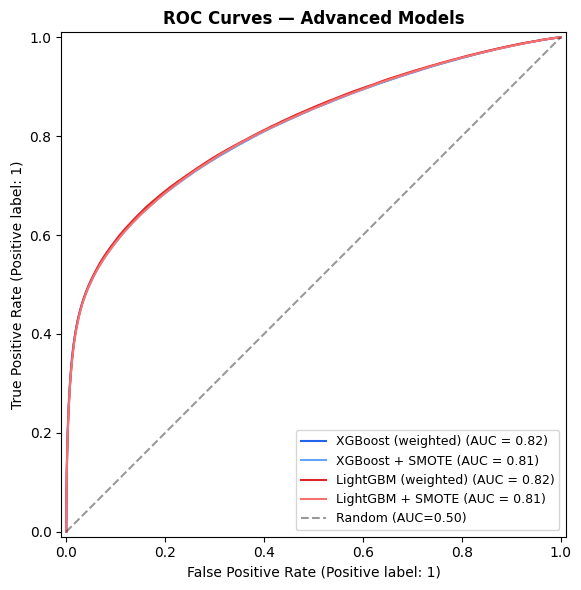

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

models = [
    ("XGBoost (weighted)", y_prob_xgb, "#2563EB"),
    ("XGBoost + SMOTE", y_prob_xgb_s, "#60A5FA"),
    ("LightGBM (weighted)", y_prob_lgbm, "#DC2626"),
    ("LightGBM + SMOTE", y_prob_lgbm_s, "#F87171"),
]

for name, y_prob, color in models:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax, color=color)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.50)")
ax.set_title("ROC Curves — Advanced Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(REPORT_DIR / "advanced_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Feature importance comparison

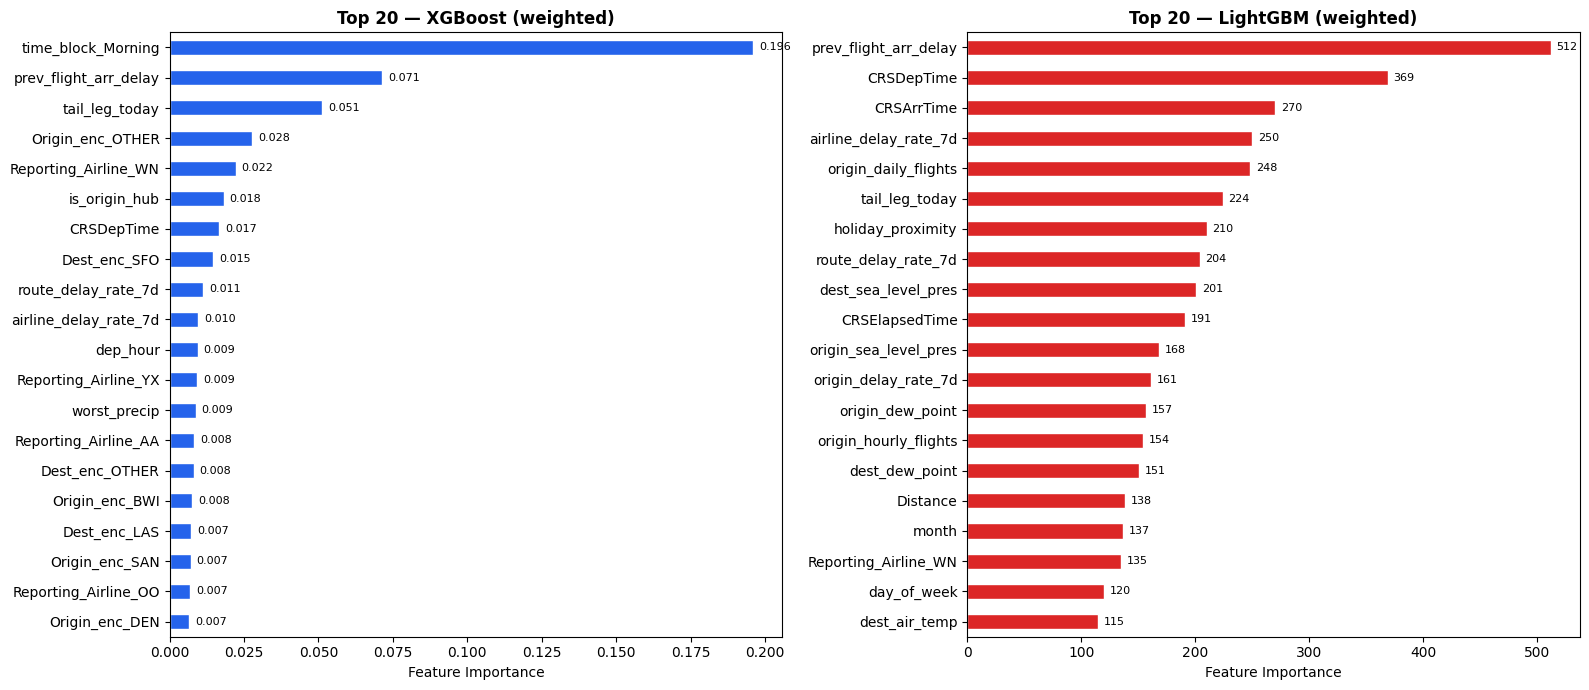

In [13]:
# Best model feature importance (XGBoost weighted as reference)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, title in [
    (axes[0], xgb, "XGBoost (weighted)"),
    (axes[1], lgbm, "LightGBM (weighted)"),
]:
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    top20 = imp.nlargest(20)
    top20.sort_values().plot.barh(ax=ax, color="#2563EB" if "XGB" in title else "#DC2626",
                                  edgecolor="white")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 20 — {title}", fontweight="bold")
    for i, (val, name) in enumerate(zip(top20.sort_values(), top20.sort_values().index)):
        ax.text(val + imp.max() * 0.01, i, f"{val:.0f}" if val > 1 else f"{val:.3f}",
                va="center", fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / "advanced_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: SMOTE impact analysis

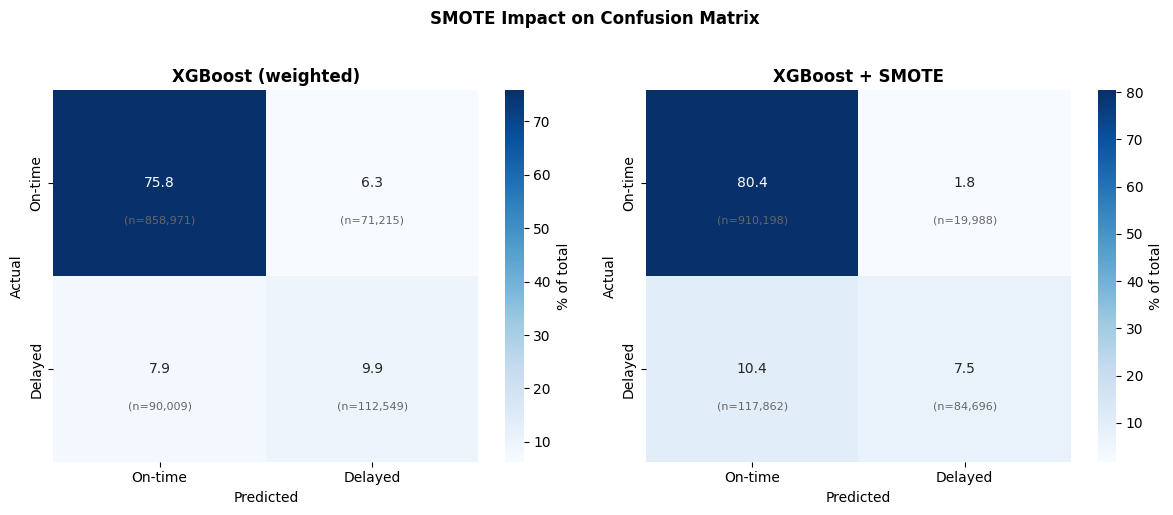

In [14]:
# Compare confusion matrices: weighted vs SMOTE for best model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_xgb, "XGBoost (weighted)"),
    (axes[1], y_pred_xgb_s, "XGBoost + SMOTE"),
]:
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                xticklabels=["On-time", "Delayed"],
                yticklabels=["On-time", "Delayed"],
                cbar_kws={"label": "% of total"})
    # Add raw counts
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.7, f"(n={cm[i,j]:,})",
                    ha="center", va="center", fontsize=8, color="#666")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    ax.set_title(title, fontweight="bold")

plt.suptitle("SMOTE Impact on Confusion Matrix", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "smote_confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 10: Summary

In [15]:
print("=" * 85)
print("ADVANCED MODEL RESULTS SUMMARY")
print("=" * 85)
print(f"Train: {len(X_train):,} flights (stratified sample, Jan–Oct 2024)")
print(f"SMOTE: {len(X_train_smote):,} flights (after oversampling)")
print(f"Test:  {len(X_test):,} flights (Nov–Dec 2024)")
print(f"Features: {X_train.shape[1]}")
print()
print(all_results.to_string(index=False, float_format="{:.4f}".format))
print()

# Best model
best = all_results.loc[all_results["AUC-ROC"].idxmax()]
print(f"Best model: {best['Model']} (AUC-ROC = {best['AUC-ROC']:.4f})")
print()
print("Key findings:")
print("  1. Gradient boosted models outperform baseline LR and RF")
print("  2. SMOTE trades precision for recall — catches more delays but more false alarms")
print("  3. Built-in class weights vs SMOTE: comparable AUC, different precision/recall tradeoff")
print("=" * 85)

ADVANCED MODEL RESULTS SUMMARY
Train: 500,000 flights (stratified sample, Jan–Oct 2024)
SMOTE: 789,958 flights (after oversampling)
Test:  1,132,744 flights (Nov–Dec 2024)
Features: 134

                 Model  Accuracy  Precision  Recall     F1  AUC-ROC
Naive (always on-time)    0.8212     0.0000  0.0000 0.0000   0.5000
   Logistic Regression    0.8169     0.4879  0.4760 0.4819   0.7553
         Random Forest    0.8532     0.5982  0.5454 0.5706   0.8039
    XGBoost (weighted)    0.8577     0.6125  0.5556 0.5827   0.8151
       XGBoost + SMOTE    0.8783     0.8091  0.4181 0.5513   0.8144
   LightGBM (weighted)    0.8511     0.5852  0.5743 0.5797   0.8169
      LightGBM + SMOTE    0.8777     0.7970  0.4244 0.5539   0.8149

Best model: LightGBM (weighted) (AUC-ROC = 0.8169)

Key findings:
  1. Gradient boosted models outperform baseline LR and RF
  2. SMOTE trades precision for recall — catches more delays but more false alarms
  3. Built-in class weights vs SMOTE: comparable AUC, differ